<a href="https://colab.research.google.com/github/Krishnavenia68/assignment/blob/main/BigBasket_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import sqlite3

In [2]:
import os
os.listdir()

['.config', 'BigBasket.csv', 'sample_data']

In [4]:
df=pd.read_csv("BigBasket.csv")
df.head()

,ProductName,Brand,Price,DiscountPrice,Image_Url,Quantity,Category,SubCategory,Absolute_Url
0,Onion (Loose),Fresho,69.75,52.0,https://www.bigbasket.com/media/uploads/p/l/40...,2 kg,Fruits & Vegetables,"Potato, Onion & Tomato",https://www.bigbasket.com/pd/40075537/fresho-o...
1,Onion,Fresho,174.35,130.0,https://www.bigbasket.com/media/uploads/p/l/12...,5 kg,Fruits & Vegetables,"Potato, Onion & Tomato",https://www.bigbasket.com/pd/1201414/fresho-on...
2,Onion (Loose),Fresho,34.87,26.0,https://www.bigbasket.com/media/uploads/p/l/10...,1 kg,Fruits & Vegetables,"Potato, Onion & Tomato",https://www.bigbasket.com/pd/10000148/fresho-o...
3,Onion,Fresho,69.74,52.0,https://www.bigbasket.com/media/uploads/p/l/12...,2 kg,Fruits & Vegetables,"Potato, Onion & Tomato",https://www.bigbasket.com/pd/1201413/fresho-on...
4,Onion (Loose),Fresho,174.37,129.0,https://www.bigbasket.com/media/uploads/p/l/10...,5 kg,Fruits & Vegetables,"Potato, Onion & Tomato",https://www.bigbasket.com/pd/10000150/fresho-o...


In [5]:
df.shape


(8208, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8208 entries, 0 to 8207
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ProductName    8208 non-null   object 
 1   Brand          8208 non-null   object 
 2   Price          8208 non-null   float64
 3   DiscountPrice  8208 non-null   float64
 4   Image_Url      8208 non-null   object 
 5   Quantity       8208 non-null   object 
 6   Category       8208 non-null   object 
 7   SubCategory    8208 non-null   object 
 8   Absolute_Url   8208 non-null   object 
dtypes: float64(2), object(7)
memory usage: 577.3+ KB


In [7]:
df.isnull().sum()

,0
ProductName,0
Brand,0
Price,0
DiscountPrice,0
Image_Url,0
Quantity,0
Category,0
SubCategory,0
Absolute_Url,0


In [8]:
df.shape

(8208, 9)

In [9]:
df.columns

Index(['ProductName', 'Brand', 'Price', 'DiscountPrice', 'Image_Url',
       'Quantity', 'Category', 'SubCategory', 'Absolute_Url'],
      dtype='object')

In [10]:
print("Total Products:", len(df))

Total Products: 8208


In [16]:
print("Total Categories:", df['Category'].nunique())

Total Categories: 11


In [17]:
df['Brand'].value_counts().head(10)

,count
Brand,
Fresho,479
BB Royal,410
BB Home,183
Healthvit,98
Soulflower,88
DP,88
GoodDiet,87
Lakme,84
Nivea,83


In [18]:
df['Price'].mean()

np.float64(545.4185891812865)

In [19]:
df[['ProductName','Price']].sort_values(
    by='Price',
    ascending=False
).head(1)

,ProductName,Price
7923,"Pet Food - For Giant Junior Dogs, -",10140.0


In [20]:
df[['ProductName','Price']].sort_values(
    by='Price',
    ascending=True
).head(1)

,ProductName,Price
129,Sunrise Instant Coffee,5.0


In [21]:
df.groupby('Category')['ProductName'].count().sort_values(
    ascending=False
)

,ProductName
Category,
Beauty & Hygiene,3789
"Kitchen, Garden & Pets",1321
"Foodgrains, Oil & Masala",718
Cleaning & Household,562
Gourmet & World Food,490
Snacks & Branded Foods,408
"Eggs, Meat & Fish",360
"Bakery, Cakes & Dairy",169
Beverages,147


In [22]:
df.groupby('Brand')['ProductName'].count().sort_values(
    ascending=False
).head(10)

,ProductName
Brand,
Fresho,479
BB Royal,410
BB Home,183
Healthvit,98
DP,88
Soulflower,88
GoodDiet,87
Lakme,84
Nivea,83


In [23]:
df['Discount'] = df['Price'] - df['DiscountPrice']
df[['ProductName','Discount']].sort_values(
    by='Discount',
    ascending=False
).head(10)

,ProductName,Discount
7690,4 Burner Glaze MS Cook Top Gas Stove - Manual ...,5146.00
7689,3 Burner Glaze MS Cook Top Gas Stove - Manual ...,4646.00
7950,Aluminium Non-Stick Ceramic Coated Magic Pan -...,4256.00
4785,Extra Light Olive Oil,4029.20
7440,Extra Light Olive Oil,4029.00
7691,3 Burner Crystal MS Cook Top Gas Stove - Manua...,3646.00
6940,"3 Burner Gas Stove - Magic Glass Tables, GTMC ...",3146.00
7469,"Gas Stove-2 Burner Royale Plus Schott Glass, B...",3096.00
3553,"3 Burner Gas Stove - Marvel Plus Glass Tables,...",3096.00
6866,Shilajit,3054.35


In [24]:
df.groupby('Brand')['Price'].mean().sort_values(
    ascending=False
).head(10)

,Price
Brand,
Royal Canin,10140.000000
Prestige,7236.000000
Surya Flame,5535.000000
Mercedes-Benz,5387.500000
Lalique,4900.000000
Dkny,4866.666667
Tommy Hilfiger,4700.000000
Ciplaplast,4490.000000
Aigner,4287.500000


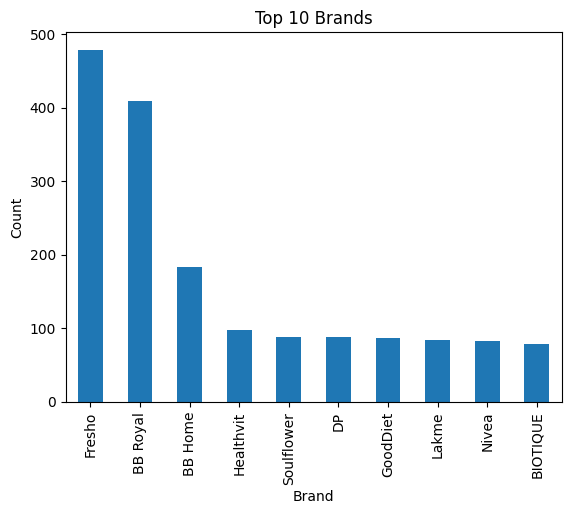

In [25]:
import matplotlib.pyplot as plt

top_brands = df['Brand'].value_counts().head(10)

top_brands.plot(kind='bar')
plt.title('Top 10 Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

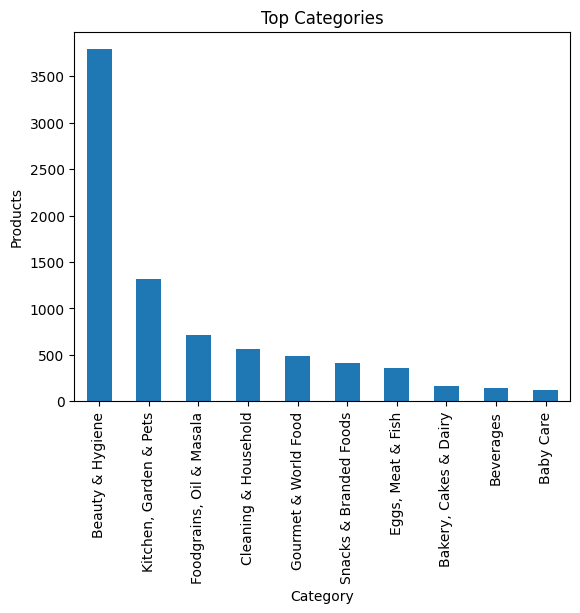

In [26]:
top_categories = df['Category'].value_counts().head(10)

top_categories.plot(kind='bar')
plt.title('Top Categories')
plt.xlabel('Category')
plt.ylabel('Products')
plt.show()

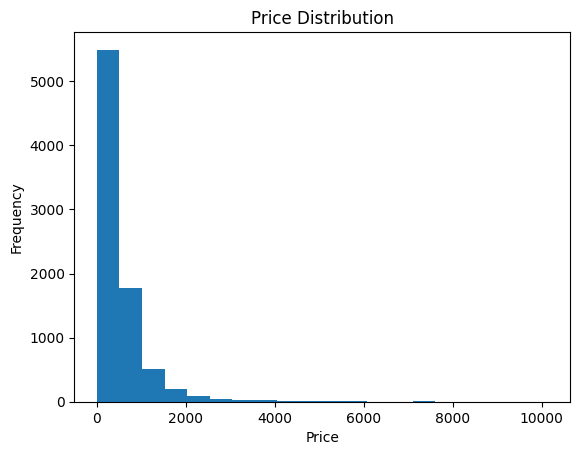

In [27]:
plt.hist(df['Price'], bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

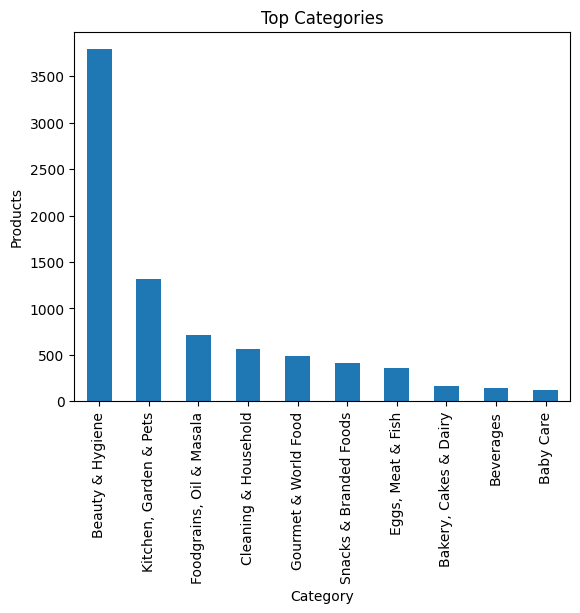

In [28]:
top_categories = df['Category'].value_counts().head(10)

top_categories.plot(kind='bar')
plt.title('Top Categories')
plt.xlabel('Category')
plt.ylabel('Products')
plt.show()